In [1]:
import gzip
import os
import tempfile
from pathlib import Path

import numpy as np
#import pooch
import scanpy as sc
import scvi
#import seaborn as sns
import torch

/home/bt392/miniconda3/envs/multiome2/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/bt392/miniconda3/envs/multiome2/lib/python3.12/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_categorical_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
/home/bt392/miniconda3/envs/multiome2/lib/python3.12/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_continuous_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)


In [2]:
import torch
print(torch.cuda.is_available())

True


In [3]:
import torch
print("CUDA Available:", torch.cuda.is_available())
print("CUDA Device Count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("CUDA Device Name:", torch.cuda.get_device_name(0))

CUDA Available: True
CUDA Device Count: 1
CUDA Device Name: NVIDIA A100-SXM4-80GB


In [35]:
data_path = '/rds/project/rds-SDzz0CATGms/users/bt392/multiome_reanalysis/results/data/2_Eo_DEG_G9_day4_VC/'

In [36]:
# read multiomic data
adata = scvi.data.read_10x_multiome(data_path)
adata.var_names_make_unique()

/home/bt392/miniconda3/envs/multiome2/lib/python3.12/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [39]:
adata.obs

""
barcode
AAACAGCCAATTAACC-1
AAACAGCCACATAGCC-1
AAACAGCCATAAGGAC-1
AAACATGCACCGGTAT-1
AAACATGCATCGTTCT-1
...
TTTGTGGCAGTTTGGC-1
TTTGTGTTCACTTCAT-1
TTTGTGTTCATAACGC-1


In [40]:
adata = adata[:, adata.var["modality"].argsort()].copy()
adata.var

,ID,modality,chr,start,end
Xkr4,ENSMUSG00000051951,Gene Expression,chr1,3671497,3671498
Gm48665,ENSMUSG00000113538,Gene Expression,chr12,88631877,88631878
4930473H19Rik,ENSMUSG00000113087,Gene Expression,chr12,88442218,88442219
3200001D21Rik,ENSMUSG00000113434,Gene Expression,chr12,88377322,88377323
Adck1,ENSMUSG00000021044,Gene Expression,chr12,88360553,88360889
...,...,...,...,...,...
chr15:55285116-55285995,chr15:55285116-55285995,Peaks,chr15,55285116,55285995
chr15:55291526-55292378,chr15:55291526-55292378,Peaks,chr15,55291526,55292378
chr15:55308858-55309626,chr15:55308858-55309626,Peaks,chr15,55308858,55309626
chr15:55440642-55441530,chr15:55440642-55441530,Peaks,chr15,55440642,55441530


In [41]:
sc.pp.filter_genes(adata, min_cells=int(adata.shape[0] * 0.01))

In [42]:
print(adata.shape)

(3975, 185681)


In [43]:
scvi.model.MULTIVI.setup_anndata(adata)

/tmp/ipykernel_2778933/3560343960.py:1: DeprecationWarning: MULTIVI is supposed to work with MuData. the use of anndata is deprecated and will be removed in scvi-tools 1.4. Please use setup_mudata
  scvi.model.MULTIVI.setup_anndata(adata)


In [56]:
model = scvi.model.MULTIVI(
    adata,
    n_genes=(adata.var["modality"] == "Gene Expression").sum(),
    n_regions=(adata.var["modality"] == "Peaks").sum(),
)
model.view_anndata_setup()

/home/bt392/miniconda3/envs/multiome2/lib/python3.12/site-packages/torch/nn/init.py:511: UserWarning: Initializing zero-element tensors is a no-op
  warnings.warn("Initializing zero-element tensors is a no-op")


Anndata setup with scvi-tools version 1.3.0.

Setup via `MULTIVI.setup_anndata` with arguments:

{
│   'layer': None,
│   'batch_key': None,
│   'size_factor_key': None,
│   'categorical_covariate_keys': None,
│   'continuous_covariate_keys': None,
│   'protein_expression_obsm_key': None,
│   'protein_names_uns_key': None
}

         Summary Statistics          
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓
┃     Summary Stat Key     ┃ Value  ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩
│         n_batch          │   1    │
│         n_cells          │  3975  │
│ n_extra_categorical_covs │   0    │
│ n_extra_continuous_covs  │   0    │
│         n_labels         │   1    │
│      n_size_factor       │   0    │
│          n_vars          │ 185681 │
└──────────────────────────┴────────┘

               Data Registry                
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Registry Key ┃    scvi-tools Location    ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      X       │          adata.X          │
│    batch     │ adata.obs['_scvi_batch']  │
│    ind_x     │   adata.obs['_indices']   │
│    labels    │ adata.obs['_scvi_labels'] │
└──────────────┴───────────────────────────┘

                     batch State Registry                      
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃     Source Location      ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['_scvi_batch'] │     0      │          0          │
└──────────────────────────┴────────────┴─────────────────────┘

                     labels State Registry                      
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃      Source Location      ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['_scvi_labels'] │     0      │          0          │
└───────────────────────────┴────────────┴─────────────────────┘

                     batch State Registry                      
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃     Source Location      ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['_scvi_batch'] │     0      │          0          │
└──────────────────────────┴────────────┴─────────────────────┘

In [60]:
model.train()

/tmp/ipykernel_2778933/1676823408.py:1: DeprecationWarning: `save_best` is deprecated in v1.2 and will be removed in v1.3. Please use `enable_checkpointing` instead. See https://github.com/scverse/scvi-tools/issues/2568 for more details.
  model.train()
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
SLURM auto-requeueing enabled. Setting signal handlers.
/home/bt392/miniconda3/envs/multiome2/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.
/home/bt392/miniconda3/envs/multiome2/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. C

Epoch 334/500:  67%|██████▋   | 334/500 [13:49<06:52,  2.48s/it, v_num=1, train_loss_step=4.71e+4, train_loss_epoch=4.88e+4]
Monitored metric reconstruction_loss_validation did not improve in the last 50 records. Best score: 53492.414. Signaling Trainer to stop.


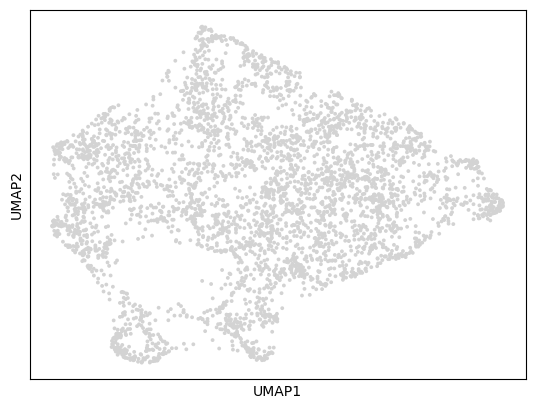

In [66]:
MULTIVI_LATENT_KEY = "X_multivi"

adata.obsm[MULTIVI_LATENT_KEY] = model.get_latent_representation()
sc.pp.neighbors(adata, use_rep=MULTIVI_LATENT_KEY, n_neighbors = 25)
sc.tl.umap(adata, min_dist=0.2)
sc.pl.umap(adata)

In [62]:
imputed_expression = model.get_normalized_expression()

In [63]:
# Saving count data
adata.layers["counts"] = adata.X.copy()

In [64]:
# Normalizing to median total counts
sc.pp.normalize_total(adata)
# Logarithmize the data
sc.pp.log1p(adata)

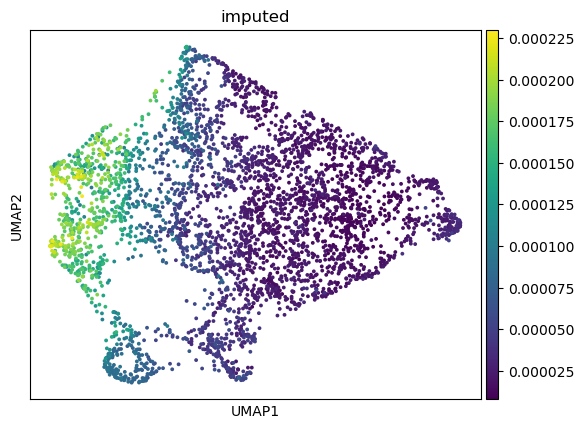

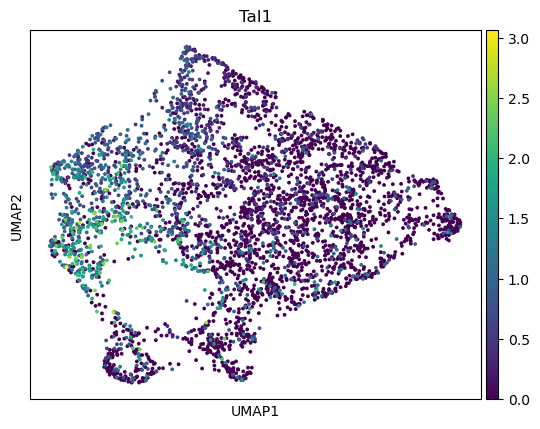

In [72]:
gene = "Tal1"
gene_idx = np.where(adata.var.index == gene)[0]
adata.obs["imputed"] = imputed_expression.iloc[:, gene_idx]
sc.pl.umap(adata, color="imputed")
sc.pl.umap(adata, color=gene)